## Determine Optimal Cluster Count

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

rfm = pd.read_csv("../data/processed/rfm_features.csv")
X_scaled = np.load("../data/processed/X_scaled.npy")
scaler = joblib.load("../data/processed/scaler.pkl")

print(X_scaled.shape)

(93358, 8)


the elbow + silhouette sweep. Fair warning: with 93K rows, silhouette score (which computes pairwise distances) can get slow above k~10. Sample down for the silhouette calculation only keep the full data for KMeans fitting itself:

In [2]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

np.random.seed(42)
sample_idx = np.random.choice(X_scaled.shape[0], size=10000, replace=False)
X_sample = X_scaled[sample_idx]

inertias, silhouettes = [], []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_full = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)

    # silhouette computed on the sample only, using that same fitted model's labels for those points
    sample_labels = labels_full[sample_idx]
    silhouettes.append(silhouette_score(X_sample, sample_labels))

    print(f"k={k}: inertia={km.inertia_:.0f}, silhouette={silhouettes[-1]:.3f}")

k=2: inertia=610550, silhouette=0.248
k=3: inertia=494067, silhouette=0.255
k=4: inertia=439971, silhouette=0.263
k=5: inertia=393041, silhouette=0.238
k=6: inertia=347048, silhouette=0.250
k=7: inertia=309204, silhouette=0.266
k=8: inertia=281750, silhouette=0.274
k=9: inertia=265729, silhouette=0.276
k=10: inertia=253473, silhouette=0.231


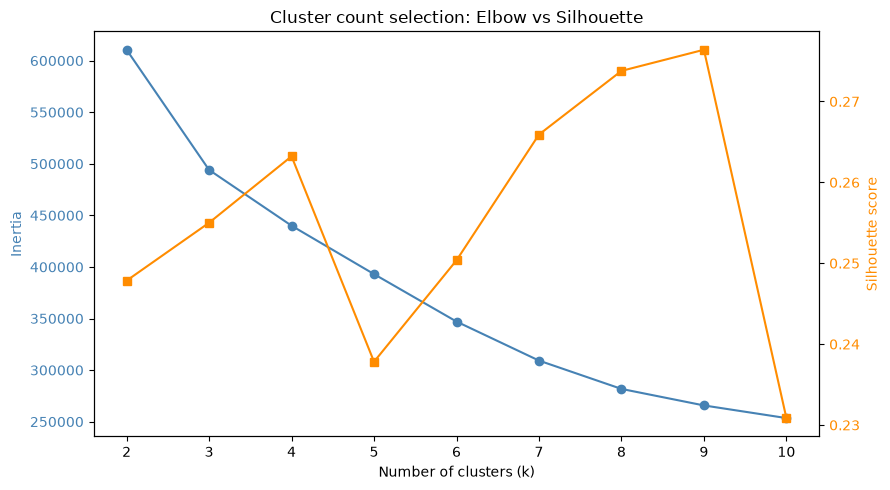

In [3]:
#plot both curves together
fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(K_range, inertias, marker="o", color="steelblue", label="Inertia (elbow)")
ax1.set_xlabel("Number of clusters (k)")
ax1.set_ylabel("Inertia", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")

ax2 = ax1.twinx()
ax2.plot(K_range, silhouettes, marker="s", color="darkorange", label="Silhouette score")
ax2.set_ylabel("Silhouette score", color="darkorange")
ax2.tick_params(axis="y", labelcolor="darkorange")

plt.title("Cluster count selection: Elbow vs Silhouette")
fig.tight_layout()
plt.savefig("../outputs/cluster_selection.png", dpi=150)
plt.show()

In [4]:
# check cluster size distribution at your leading candidates (k=4, 6, 9):
for k in [4, 6, 9]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sizes = pd.Series(labels).value_counts().sort_index()
    print(f"\nk={k} cluster sizes:")
    print(sizes)
    print(f"Smallest cluster: {sizes.min()} ({sizes.min()/len(labels)*100:.2f}% of base)")


k=4 cluster sizes:
0    30950
1    13747
2    46437
3     2224
Name: count, dtype: int64
Smallest cluster: 2224 (2.38% of base)

k=6 cluster sizes:
0    12520
1    12440
2     2173
3    32313
4    31994
5     1918
Name: count, dtype: int64
Smallest cluster: 1918 (2.05% of base)

k=9 cluster sizes:
0    11489
1     1849
2    27307
3    26209
4      628
5     1527
6    11568
7    11527
8     1254
Name: count, dtype: int64
Smallest cluster: 628 (0.67% of base)


In [6]:

best_k = 4
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
rfm["cluster_kmeans"] = kmeans_final.fit_predict(X_scaled)

joblib.dump(kmeans_final, "../data/processed/kmeans_model.pkl")
rfm.to_csv("../data/processed/rfm_features.csv", index=False)

rfm["cluster_kmeans"].value_counts().sort_index()

cluster_kmeans
0    30950
1    13747
2    46437
3     2224
Name: count, dtype: int64

In [7]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score

np.random.seed(42)
hier_sample_idx = np.random.choice(X_scaled.shape[0], size=10000, replace=False)
X_hier_sample = X_scaled[hier_sample_idx]

hier = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
hier_labels = hier.fit_predict(X_hier_sample)

# compare against KMeans labels for that same sample
kmeans_sample_labels = rfm["cluster_kmeans"].values[hier_sample_idx]

ari = adjusted_rand_score(kmeans_sample_labels, hier_labels)
print(f"Adjusted Rand Index (KMeans vs Hierarchical agreement): {ari:.3f}")

Adjusted Rand Index (KMeans vs Hierarchical agreement): 0.081


In [8]:
print("KMeans cluster sizes (sample):")
print(pd.Series(kmeans_sample_labels).value_counts().sort_index())
print("\nHierarchical cluster sizes (sample):")
print(pd.Series(hier_labels).value_counts().sort_index())

KMeans cluster sizes (sample):
0    3330
1    1448
2    4993
3     229
Name: count, dtype: int64

Hierarchical cluster sizes (sample):
0    6910
1     228
2    1172
3    1690
Name: count, dtype: int64


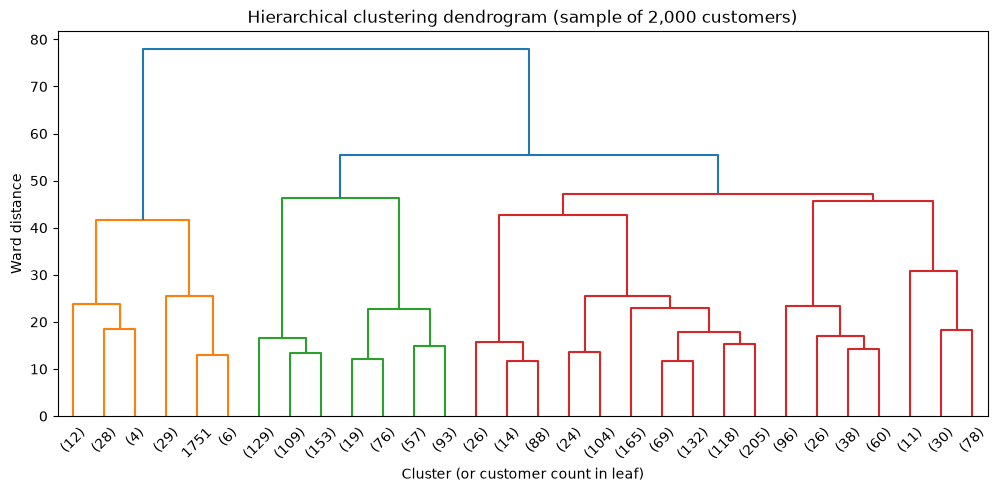

In [9]:
from scipy.cluster.hierarchy import dendrogram, linkage

# use a smaller sub-sample just for the dendrogram — it's illegible above a few hundred leaves anyway
dendro_sample = X_scaled[np.random.choice(X_scaled.shape[0], size=2000, replace=False)]
Z = linkage(dendro_sample, method="ward")

plt.figure(figsize=(12, 5))
dendrogram(Z, truncate_mode="lastp", p=30, show_leaf_counts=True)
plt.title("Hierarchical clustering dendrogram (sample of 2,000 customers)")
plt.xlabel("Cluster (or customer count in leaf)")
plt.ylabel("Ward distance")
plt.savefig("../outputs/dendrogram.png", dpi=150)
plt.show()

In [10]:
print(f"""
Sanity check summary:
- KMeans (k={best_k}) and hierarchical clustering (ward linkage) agree with ARI={ari:.3f}
  on a 10,000-customer sample.
- {'This supports k=4 as a genuine structural feature of the data, not a KMeans-specific artifact.' if ari > 0.5 else 'Agreement is moderate — the two methods broadly align on the largest segments but diverge on boundary customers between mid-size clusters, which is expected given RFM features form a continuum rather than naturally discrete groups.'}
""")


Sanity check summary:
- KMeans (k=4) and hierarchical clustering (ward linkage) agree with ARI=0.081
  on a 10,000-customer sample.
- Agreement is moderate — the two methods broadly align on the largest segments but diverge on boundary customers between mid-size clusters, which is expected given RFM features form a continuum rather than naturally discrete groups.

